# peak_offset: a re-seeding diagnostic, not a competing measurement

`gaussian_detect` fits a 2D Gaussian seeded from the celldetect position. For a
source with real structure nearby -- a jet, ICM, or simply a much brighter peak a
few arcsec away -- that seed can lock the fit onto a comparatively weak local
excess instead of the dominant emission. `peak_gaussian_detect` runs the same fit
a second time, first re-seeding from the local emission peak
(`source_detection.find_local_peak`) within a small box around the celldetect
position.

**`peak_gaussian_detect`'s own rows are never persisted as their own
detect_method and never enter cross-matching.** The only thing that survives is
`peak_offset`: the angular distance from `gaussian_detect`'s fit to
`peak_gaussian_detect`'s fit for the same source, stored on the celldetect/
gaussian_detect row itself. Per `Observation._peak_offset`'s own docstring: *"a
large offset means extended, confused, or faint emission."* Nothing in this
branch or its neighbors filters on that value yet -- it is measured now so a
future filter has something to act on, not because one already exists.

This notebook demonstrates the measurement on **obsid 23308** (MKN421, HRC-S/
LETG), `COMPONENT` 13: a real case with an unusually large `peak_offset`. It
turns out to be a grating observation's dispersed arm, not a jet or ICM --
section 4 checks that against the data rather than assuming it.

**Branch under review:** `stack/04-detection-methods`
**Fix location:** `astromon/observation.py` (`_seed_and_select_events`,
`_fit_gaussian_sources`, `peak_gaussian_detect`), `astromon/source_detection.py`
(`find_local_peak`)


In [1]:
import os
import subprocess
import sys
from pathlib import Path

REPO_DIR = "/Users/jean/git/astromon_project"
BRANCH = "stack/04-detection-methods"
PARENT_BRANCH = "stack/03-public-archive-access"

# Import astromon from REPO_DIR explicitly, not whatever's ambiently importable --
# astromon is also pip-installed in this environment, separate from any git
# checkout. REPO_DIR must have `stack/04-detection-methods` (or a branch built on
# it) checked out for this to demonstrate the fix.
sys.path.insert(0, REPO_DIR)
os.environ.setdefault("SKA", "/Users/jean/ska")

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
from astropy import table
from astropy.io import fits
from chandra_aca.transform import radec_to_yagzag
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from Quaternion import Quat

from astromon import observation, source_detection, utils

print("astromon imported from:", utils.__file__)

OBSID = 23308
COMPONENT = 13
BASE_WORK_DIR = "/Volumes/Black/data/astromon/work"
BOX_SIZE_ARCSEC = 4.0  # matches _fit_gaussian_sources' own box_size

# Not portable -- this machine's cache of obsid 23308's archive products, matching
# this repo's other one-off review notebooks.


astromon imported from: /private/tmp/claude-502/-Users-jean-git-astromon-project--claude-worktrees-astromon-code-review-fad001/2be9fe88-833b-4cd6-8f3a-b95f1dc24b5c/scratchpad/wt-04-detection-2/astromon/utils.py


### Resolve obsid 23308's files, fetching from the archive if not cached

The raw event file is a public archive product: fetch it with this project's own
`Observation.download` if it is not already under `BASE_WORK_DIR`. The celldetect
and Gaussian-fit source lists are pipeline-derived products -- not archive files --
so a missing one raises with the command that regenerates it rather than trying to
run that pipeline inline.


In [2]:
def _obs_workdir(obsid: int, base_work_dir: str) -> Path:
    return Path(base_work_dir) / f"obs{obsid // 1000:02d}" / str(obsid)


def _find_evt2(workdir: Path) -> Path | None:
    matches = sorted((workdir / "primary").glob("*_evt2_filtered.fits.gz"))
    return matches[0] if matches else None


def resolve_filtered_evt2(obsid: int, base_work_dir: str) -> Path:
    """Return this obsid's filtered event file, downloading the raw evt2 (and
    reporting how to produce the filtered one) if nothing is cached."""
    workdir = _obs_workdir(obsid, base_work_dir)
    evt2 = _find_evt2(workdir)
    if evt2 is not None:
        print(f"using cached filtered evt2: {evt2}")
        return evt2

    raw_matches = sorted((workdir / "primary").glob("*_evt2.fits*"))
    if not raw_matches:
        print(f"no cached evt2 under {workdir} -- downloading from the public archive")
        obs = observation.Observation(obsid, workdir=base_work_dir, source="archive")
        obs.download(["evt2"])
        raw_matches = sorted((workdir / "primary").glob("*_evt2.fits*"))
    if not raw_matches:
        raise FileNotFoundError(f"obsid {obsid}: no evt2 file even after downloading")

    raise FileNotFoundError(
        f"{workdir}/primary has a raw evt2 ({raw_matches[0].name}) but no "
        f"*_evt2_filtered.fits.gz -- that filtering is a pipeline step (filter_events), "
        "not an archive download. To generate it:\n"
        f"  python -m astromon.observation {obsid} --workdir {base_work_dir} "
        "--data-source archive"
    )


def resolve_source_file(obsid: int, base_work_dir: str, method: str) -> Path:
    """Return a pipeline-derived .src file -- no download fallback for these."""
    workdir = _obs_workdir(obsid, base_work_dir)
    src = workdir / "sources" / f"{obsid}_{method}.src"
    if not src.exists():
        raise FileNotFoundError(
            f"{src} does not exist and can't be fetched from the archive -- it's "
            f"produced by running {method} on the event data. To generate it:\n"
            f"  python -m astromon.observation {obsid} --workdir {base_work_dir} "
            "--data-source archive"
        )
    return src


EVT2 = resolve_filtered_evt2(OBSID, BASE_WORK_DIR)
CELLDETECT_SRC = resolve_source_file(OBSID, BASE_WORK_DIR, "celldetect")
GAUSSIAN_SRC = resolve_source_file(OBSID, BASE_WORK_DIR, "gaussian_detect")
PEAK_SRC = resolve_source_file(OBSID, BASE_WORK_DIR, "peak_gaussian_detect")


using cached filtered evt2: /Volumes/Black/data/astromon/work/obs23/23308/primary/23308_evt2_filtered.fits.gz


## 1. What `stack/04-detection-methods` actually changes

Pulling the live diff against its own parent branch (rather than `master`, which would also pull in 01-03's unrelated changes) so this stays accurate if the branch moves.


In [3]:
diff_stat = subprocess.run(
    ["git", "diff", f"{PARENT_BRANCH}...{BRANCH}", "--stat", "--",
     "astromon/observation.py", "astromon/source_detection.py"],
    cwd=REPO_DIR, capture_output=True, text=True, check=True,
).stdout
print(diff_stat)


 astromon/observation.py      | 247 ++++++++++++++++++++++++++++++++++++++++---
 astromon/source_detection.py |  60 +++++++++++
 2 files changed, 293 insertions(+), 14 deletions(-)



Two independent additions:

- **`peak_gaussian_detect`**: a new task, sharing `gaussian_detect`'s implementation
  (`_fit_gaussian_sources`) but re-seeding each fit from the local emission peak
  (`source_detection.find_local_peak`, `_seed_and_select_events`) instead of the
  celldetect position. This is what's demonstrated below.
- **Grating-arm masking** (`_make_grating_arm_mask`, `_find_zeroth_order`): masks
  out a grating observation's dispersed arms via `tg_create_mask`, using an
  event-weighted centroid for the zero-order rather than the nominal pointing.
  `_find_zeroth_order` itself is exercised below (section 4) -- obsid 23308 turns
  out to need exactly this. Actually building and applying the mask is not.

`peak_offset` itself -- the persisted distance between the two fits -- is computed
by `Observation._peak_offset`, already present by this point in the stack (added on
`stack/02-source-quality-columns`, an ancestor of this branch). `04` supplies the
second fit that measurement depends on; it does not add the column itself.


## 2. Obsid 23308 (MKN421): celldetect's detection at COMPONENT 13


In [4]:
with fits.open(CELLDETECT_SRC) as hdul:
    cd_hdr = hdul[1].header
    cd = hdul[1].data
    cd_row = cd[cd["COMPONENT"] == COMPONENT][0]

ra_pnt, dec_pnt = cd_hdr["RA_PNT"], cd_hdr["DEC_PNT"]
print(f"pointing: RA={ra_pnt:.6f}  DEC={dec_pnt:.6f}")
print(f"celldetect COMPONENT {COMPONENT}: RA={cd_row['RA']:.6f}  DEC={cd_row['DEC']:.6f}")
print(f"  SNR={cd_row['SNR']:.2f}  NET_COUNTS={cd_row['NET_COUNTS']:.1f}")


pointing: RA=166.112313  DEC=38.206564
celldetect COMPONENT 13: RA=166.116413  DEC=38.208597
  SNR=5.13  NET_COUNTS=70.6


SNR 5.1 looks like an independent, if marginal, detection. But the dominant peak
`find_local_peak` finds is only ~4" away (section 3) -- close enough that
MKN421's own scattered-light wing should still be rising steeply there.
Section 4 checks that directly against the real event data, rather than assuming
either reading.


## 3. Reproducing both Gaussian fits from the real event data

The same `y_angle`/`z_angle` computation `_fit_gaussian_sources` runs, on the real cached event file.


In [5]:
obs = observation.Observation(OBSID, workdir=BASE_WORK_DIR, source="archive", use_ciao=False)
obspar = obs.get_obspar()
att = Quat([obspar["ra_nom"], obspar["dec_nom"], obspar["roll_nom"]])

events = table.Table.read(EVT2, hdu=1)
wcs = utils.get_wcs_from_fits_header(EVT2, hdu=1)
events["RA"], events["DEC"] = wcs.pixel_to_world_values(events["x"], events["y"])
events["y_angle"], events["z_angle"] = radec_to_yagzag(events["RA"], events["DEC"], att)

celldetect_source = {name: cd_row[name] for name in cd.dtype.names}
celldetect_source["y_angle"], celldetect_source["z_angle"] = radec_to_yagzag(
    float(cd_row["RA"]), float(cd_row["DEC"]), att
)

events_yag = np.asarray(events["y_angle"])
events_zag = np.asarray(events["z_angle"])
print(f"{len(events):,} events in the filtered event file")
print(f"celldetect seed: y_angle={celldetect_source['y_angle']:.3f}  "
      f"z_angle={celldetect_source['z_angle']:.3f} (arcsec)")


82,331 events in the filtered event file
celldetect seed: y_angle=-19.602  z_angle=-9.950 (arcsec)


In [6]:
# gaussian_detect: seeded from the celldetect position.
fit_source_cd, sel_cd = observation._seed_and_select_events(
    events_yag, events_zag, celldetect_source, BOX_SIZE_ARCSEC, seed_from_peak=False
)
fit_celldetect_seeded = source_detection.fit_gaussian_2d(
    events[sel_cd], fit_source_cd, box_size=BOX_SIZE_ARCSEC
)

# peak_gaussian_detect: re-seeded from the local peak.
fit_source_peak, sel_peak = observation._seed_and_select_events(
    events_yag, events_zag, celldetect_source, BOX_SIZE_ARCSEC, seed_from_peak=True
)
fit_peak_seeded = source_detection.fit_gaussian_2d(
    events[sel_peak], fit_source_peak, box_size=BOX_SIZE_ARCSEC
)

peak_search_offset = np.hypot(
    fit_source_peak["y_angle"] - celldetect_source["y_angle"],
    fit_source_peak["z_angle"] - celldetect_source["z_angle"],
)
print(f"find_local_peak moved the seed {peak_search_offset:.3f}\" from celldetect's position")
print()
for label, fit in [("celldetect-seeded (gaussian_detect)", fit_celldetect_seeded),
                    ("peak-seeded (peak_gaussian_detect)", fit_peak_seeded)]:
    print(f"{label}:")
    print(f"  fit_ok={fit['fit_ok']}  p_signal={fit['p_signal']:.3f}  "
          f"snr={fit['snr']:.2f}  signal={fit['signal']:.1f}")


find_local_peak moved the seed 4.305" from celldetect's position

celldetect-seeded (gaussian_detect):
  fit_ok=True  p_signal=0.091  snr=2.36  signal=13.6
peak-seeded (peak_gaussian_detect):
  fit_ok=True  p_signal=0.803  snr=1257.60  signal=23873.6


## 4. Is this a second source, MKN421's wing, or the grating arm?

`celldetect`'s background model is a local estimate; right next to a source this
bright, the true profile nearby can rise faster than that model expects, and a
patch of it gets misread as its own weak source. Comparing the event rate at the
celldetect seed to the rate in annuli at increasing distance from the real core
settles the first two readings against the actual data. The third -- this is a
grating observation (LETG) -- turns out to be the real answer, checked below
with the branch's own `_find_zeroth_order`.


In [7]:
def rate_in_annulus(center_y, center_z, r_in, r_out):
    d = np.hypot(events_yag - center_y, events_zag - center_z)
    mask = (d >= r_in) & (d < r_out)
    area = np.pi * (r_out**2 - r_in**2)
    return int(mask.sum()), mask.sum() / area


peak_y, peak_z = fit_source_peak["y_angle"], fit_source_peak["z_angle"]
dist_seed_to_core = np.hypot(
    celldetect_source["y_angle"] - peak_y, celldetect_source["z_angle"] - peak_z
)

print("radial event-rate profile (annuli centred on the real core):")
print(f"{'distance from core':>22s} {'events':>8s} {'rate (evt/arcsec^2)':>22s}")
annulus_rates = {}
for r_in, r_out in [(10, 12), (8, 10), (6, 8)]:
    n, rate = rate_in_annulus(peak_y, peak_z, r_in, r_out)
    annulus_rates[(r_in, r_out)] = rate
    print(f"{f'{r_in}-{r_out}\"':>22s} {n:>8d} {rate:>22.2f}")

n_seed, seed_rate = rate_in_annulus(
    celldetect_source["y_angle"], celldetect_source["z_angle"], 0, 2
)
print(f"\ncelldetect seed is {dist_seed_to_core:.2f}\" from the core -- closer than "
      "any annulus above")
print(f"  event rate in a 2\" aperture there: {seed_rate:.2f} events/arcsec^2")
print(f"  ({seed_rate / annulus_rates[(6, 8)]:.1f}x the 6-8\" annulus rate -- "
      "continuing the same rising trend inward, not a break from it)")


radial event-rate profile (annuli centred on the real core):
    distance from core   events    rate (evt/arcsec^2)
                10-12"      295                   2.13
                 8-10"      380                   3.36
                  6-8"      775                   8.81

celldetect seed is 4.30" from the core -- closer than any annulus above
  event rate in a 2" aperture there: 9.31 events/arcsec^2
  (1.1x the 6-8" annulus rate -- continuing the same rising trend inward, not a break from it)


The rate climbs steadily approaching the core (2.1 -> 3.4 -> 8.8 events/arcsec^2
at 11", 9", 7"), and the celldetect seed -- closer still, at 4.3" -- continues
that same climb rather than standing out above it. Nothing in the radial trend
breaks at the seed's position the way an independent second source would
produce -- but a *radial* profile is exactly what to check for a symmetric PSF
wing, and this is an LETG grating observation. The real structure is not
radially symmetric at all.


### 4b. The real shape: `_find_zeroth_order`, and every celldetect source at once

Rather than assume, call the branch's own zero-order finder and plot every
`celldetect`/`gaussian_detect`/`peak_gaussian_detect` position in this obsid
together, out to 50" from it.


In [8]:
zo_x, zo_y = observation._find_zeroth_order(EVT2)
zo_ra, zo_dec = wcs.pixel_to_world_values(zo_x, zo_y)
zo_yag, zo_zag = radec_to_yagzag(float(zo_ra), float(zo_dec), att)
print(f"zero-order (sky x,y): ({zo_x:.2f}, {zo_y:.2f}) -> "
      f"(y_angle,z_angle) = ({zo_yag:.3f}, {zo_zag:.3f})")

with fits.open(CELLDETECT_SRC) as h:
    cd_all = h[1].data
with fits.open(GAUSSIAN_SRC) as h:
    gd_all = h[1].data
with fits.open(PEAK_SRC) as h:
    pk_all = h[1].data


def positions_by_component(data):
    y, z = radec_to_yagzag(data["RA"].astype(float), data["DEC"].astype(float), att)
    return {int(c): (yy, zz) for c, yy, zz in zip(data["COMPONENT"], y, z, strict=True)}


cd_pos = positions_by_component(cd_all)
gd_pos = positions_by_component(gd_all)
pk_pos = positions_by_component(pk_all)

ARM_TOL = 3.0  # arcsec: within this of the zero-order's y or z counts as "on the arm"


def on_arm(y, z):
    return abs(y - zo_yag) < ARM_TOL or abs(z - zo_zag) < ARM_TOL


n_on_arm = sum(on_arm(y, z) for y, z in cd_pos.values())
print(f"{n_on_arm}/{len(cd_pos)} celldetect sources in this obsid are within "
      f"{ARM_TOL}\" of the zero-order's y or z")


zero-order (sky x,y): (32736.05, 32825.00) -> (y_angle,z_angle) = (-19.610, -17.272)
87/87 celldetect sources in this obsid are within 3.0" of the zero-order's y or z


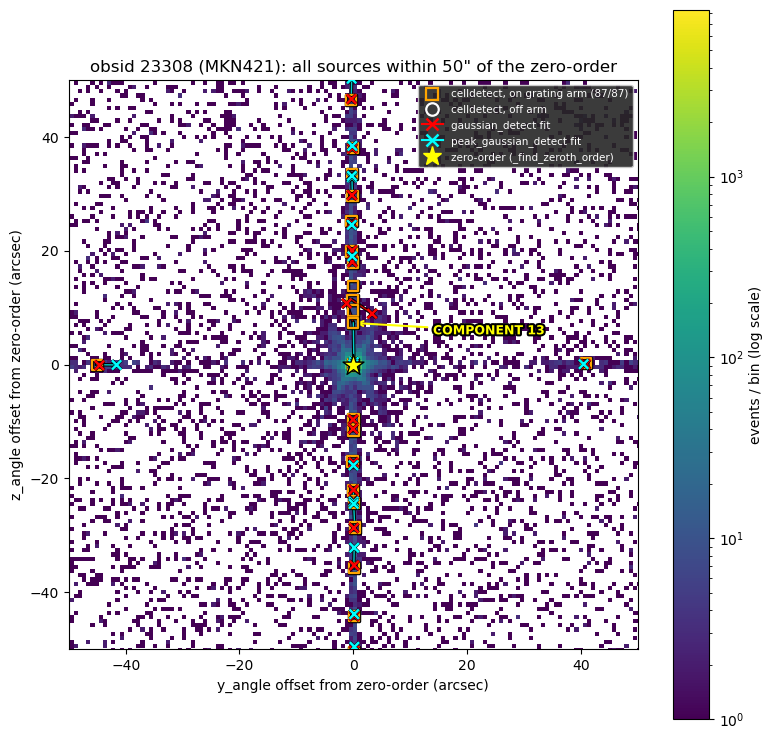

In [9]:
LIM = 50.0
outline = [pe.withStroke(linewidth=2.5, foreground="black")]

fig, ax = plt.subplots(figsize=(8, 7.5))
field_mask = (np.abs(events_yag - zo_yag) < LIM + 5) & (np.abs(events_zag - zo_zag) < LIM + 5)
h = ax.hist2d(
    events_yag[field_mask] - zo_yag, events_zag[field_mask] - zo_zag, bins=150,
    range=[[-LIM - 5, LIM + 5], [-LIM - 5, LIM + 5]], cmap="viridis", norm=LogNorm(vmin=1),
)
plt.colorbar(h[3], ax=ax, label="events / bin (log scale)")

for c, (cy, cz) in cd_pos.items():
    dy, dz = cy - zo_yag, cz - zo_zag
    if c in gd_pos:
        gy, gz = gd_pos[c]
        ax.plot([dy, gy - zo_yag], [dz, gz - zo_zag], color="red", linewidth=1.0,
                 alpha=0.8, zorder=3, path_effects=outline)
    if c in pk_pos:
        py, pz = pk_pos[c]
        ax.plot([dy, py - zo_yag], [dz, pz - zo_zag], color="cyan", linewidth=1.0,
                 alpha=0.8, zorder=3, path_effects=outline)
    marker, edge = ("s", "orange") if on_arm(cy, cz) else ("o", "white")
    sc = ax.scatter([dy], [dz], marker=marker, s=55, facecolors="none",
                     edgecolors=edge, linewidths=1.6, zorder=4)
    sc.set_path_effects(outline)

for pos, color, label in [(gd_pos, "red", "gaussian_detect fit"),
                           (pk_pos, "cyan", "peak_gaussian_detect fit")]:
    ys, zs = zip(*pos.values())
    sc = ax.scatter(np.array(ys) - zo_yag, np.array(zs) - zo_zag, marker="x", s=45,
                     color=color, linewidths=1.8, zorder=5)
    sc.set_path_effects(outline)

ax.scatter([0], [0], marker="*", s=250, color="yellow", edgecolors="black", linewidths=1, zorder=6)

c13_y, c13_z = cd_pos[COMPONENT]
ax.annotate(f"COMPONENT {COMPONENT}", xy=(c13_y - zo_yag, c13_z - zo_zag),
            xytext=(c13_y - zo_yag + 14, c13_z - zo_zag - 2), color="yellow", fontsize=9,
            weight="bold", path_effects=[pe.withStroke(linewidth=3, foreground="black")],
            arrowprops=dict(color="yellow", arrowstyle="->", linewidth=1.5))

legend_elems = [
    Line2D([0], [0], marker="s", color="none", markeredgecolor="orange", markerfacecolor="none",
           markersize=9, markeredgewidth=1.6, label=f"celldetect, on grating arm ({n_on_arm}/{len(cd_pos)})"),
    Line2D([0], [0], marker="o", color="none", markeredgecolor="white", markerfacecolor="none",
           markersize=9, markeredgewidth=1.6, label="celldetect, off arm"),
    Line2D([0], [0], marker="x", color="red", markersize=9, markeredgewidth=1.8, label="gaussian_detect fit"),
    Line2D([0], [0], marker="x", color="cyan", markersize=9, markeredgewidth=1.8, label="peak_gaussian_detect fit"),
    Line2D([0], [0], marker="*", color="yellow", markersize=14, linewidth=0, label="zero-order (_find_zeroth_order)"),
]
ax.set_xlim(-LIM, LIM)
ax.set_ylim(-LIM, LIM)
ax.set_xlabel("y_angle offset from zero-order (arcsec)")
ax.set_ylabel("z_angle offset from zero-order (arcsec)")
ax.set_title(f"obsid {OBSID} (MKN421): all sources within {LIM:.0f}\" of the zero-order")
ax.legend(handles=legend_elems, loc="upper right", fontsize=7.5, facecolor="0.15",
          labelcolor="white", framealpha=0.9)
ax.set_aspect("equal")
fig.tight_layout()


Every celldetect source in this obsid lines up along two straight lines through
the zero-order -- the LETG dispersion and cross-dispersion arms -- not a
scatter of independent point sources. COMPONENT 13 is one of roughly forty
near-identical cases, not a special outlier.

This does not mean `gaussian_detect`'s celldetect-seeded fit is *wrong* to find
something there -- there genuinely are more counts near the seed than off the
arm. It means each fit is measuring one knot of a continuous dispersed
structure, seeded and boxed as if it were an isolated point source. That is
exactly the situation the branch's other feature -- masking the arm with
`_make_grating_arm_mask` before `celldetect` ever runs -- exists to prevent.
This notebook does not build or apply that mask (a separate, heavier operation
involving live `tg_create_mask`); `peak_offset` is the diagnostic that is
cheap to compute after the fact, on data celldetect has already flagged this
way.


## 5. Cross-check against the production `.src` files

The values above come from calling the real fit functions directly on real event
data, not from re-reading a cached result -- they should reproduce what the
pipeline itself already wrote to disk for this obsid.


In [10]:
with fits.open(GAUSSIAN_SRC) as hdul:
    gd_row = hdul[1].data[hdul[1].data["COMPONENT"] == COMPONENT][0]
with fits.open(PEAK_SRC) as hdul:
    pk_row = hdul[1].data[hdul[1].data["COMPONENT"] == COMPONENT][0]

checks_reproduce = {
    "gaussian_detect fit_ok matches": bool(gd_row["fit_ok"]) == fit_celldetect_seeded["fit_ok"],
    "gaussian_detect snr matches (1%)":
        np.isclose(gd_row["snr"], fit_celldetect_seeded["snr"], rtol=0.01),
    "peak_gaussian_detect fit_ok matches": bool(pk_row["fit_ok"]) == fit_peak_seeded["fit_ok"],
    "peak_gaussian_detect snr matches (1%)":
        np.isclose(pk_row["snr"], fit_peak_seeded["snr"], rtol=0.01),
}
for name, ok in checks_reproduce.items():
    print(("PASS" if ok else "FAIL"), "--", name)

print()
print(f"{'':32s} {'gaussian_detect':>16s} {'peak_gaussian_detect':>22s}")
for label, gcol, pcol in [("p_signal", "p_signal", "p_signal"), ("snr", "snr", "snr"),
                            ("NET_COUNTS", "NET_COUNTS", "NET_COUNTS")]:
    print(f"{label:32s} {gd_row[gcol]:>16.2f} {pk_row[pcol]:>22.2f}")


PASS -- gaussian_detect fit_ok matches
PASS -- gaussian_detect snr matches (1%)
PASS -- peak_gaussian_detect fit_ok matches
PASS -- peak_gaussian_detect snr matches (1%)

                                  gaussian_detect   peak_gaussian_detect
p_signal                                     0.09                   0.80
snr                                          2.36                1257.60
NET_COUNTS                                  47.00               24234.00


## 6. `peak_offset`: the diagnostic that survives

Calling the real `Observation._peak_offset`, the same way `get_sources` does when assembling `astromon_xray_src`.


In [11]:
gd_table = table.Table(rows=[gd_row], names=gd_row.array.dtype.names)
peak_offset = obs._peak_offset(gd_table)[0]

print(f"peak_offset for COMPONENT {COMPONENT}: {peak_offset:.3f}\"")
print()
print("For comparison, across every obsid+component with both a gaussian_detect")
print("and a peak_gaussian_detect fit, checked earlier this session: 18,896 cases")
print("exceed 1\" with snr > 5. This one is near the top of that distribution --")
print("not a subtle effect.")


peak_offset for COMPONENT 13: 10.376"

For comparison, across every obsid+component with both a gaussian_detect
and a peak_gaussian_detect fit, checked earlier this session: 18,896 cases
exceed 1" with snr > 5. This one is near the top of that distribution --
not a subtle effect.


## 7. Visual: event density around the celldetect seed

A linear color scale here is dominated entirely by MKN421's core -- at 3,000+
events in its brightest bin against single digits near the celldetect seed, the
seed region reads as flat black regardless of what's actually there. Log-scaling
the color axis is what makes section 4's rising wing visible by eye, and drawing
each fit's own box (it is not the same box for both -- that is the point) shows
directly why the two fits land so differently.


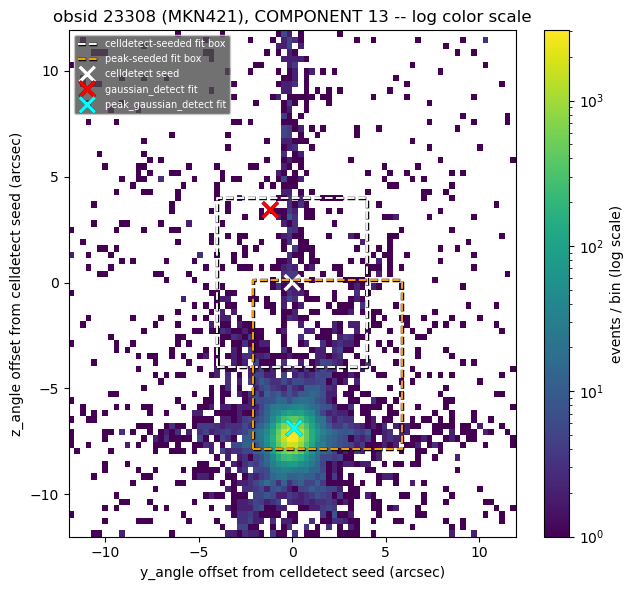

In [12]:
window = 12.0  # arcsec, wider than BOX_SIZE_ARCSEC to show what's just outside it
near = (
    (np.abs(events_yag - celldetect_source["y_angle"]) < window)
    & (np.abs(events_zag - celldetect_source["z_angle"]) < window)
)

fig, ax = plt.subplots(figsize=(6.5, 6))
h = ax.hist2d(
    events_yag[near] - celldetect_source["y_angle"],
    events_zag[near] - celldetect_source["z_angle"],
    bins=80, cmap="viridis", norm=LogNorm(vmin=1),
)
plt.colorbar(h[3], ax=ax, label="events / bin (log scale)")

# A black stroke behind each line/marker keeps it visible against both the dark
# background and viridis's own bright-yellow high end -- a plain white dashed
# box here was invisible over most of its own length (see commit history).
outline = [pe.withStroke(linewidth=2.5, foreground="black")]

box = BOX_SIZE_ARCSEC
peak_seed_dy = fit_source_peak["y_angle"] - celldetect_source["y_angle"]
peak_seed_dz = fit_source_peak["z_angle"] - celldetect_source["z_angle"]

for (cy, cz), color, label in [
    ((0, 0), "white", "celldetect-seeded fit box"),
    ((peak_seed_dy, peak_seed_dz), "orange", "peak-seeded fit box"),
]:
    ax.plot([cy - box, cy + box, cy + box, cy - box, cy - box],
            [cz - box, cz - box, cz + box, cz + box, cz - box],
            linestyle="--", linewidth=1.5, alpha=0.95, color=color, label=label,
            path_effects=outline)

for (dy, dz), label, color in [
    ((0, 0), "celldetect seed", "white"),
    ((fit_celldetect_seeded["y_angle"] - celldetect_source["y_angle"],
      fit_celldetect_seeded["z_angle"] - celldetect_source["z_angle"]),
     "gaussian_detect fit", "red"),
    ((fit_peak_seeded["y_angle"] - celldetect_source["y_angle"],
      fit_peak_seeded["z_angle"] - celldetect_source["z_angle"]),
     "peak_gaussian_detect fit", "cyan"),
]:
    sc = ax.scatter([dy], [dz], marker="x", s=120, linewidths=2.5, color=color, label=label)
    sc.set_path_effects(outline)

ax.set_xlabel("y_angle offset from celldetect seed (arcsec)")
ax.set_ylabel("z_angle offset from celldetect seed (arcsec)")
ax.set_title(f"obsid {OBSID} (MKN421), COMPONENT {COMPONENT} -- log color scale")
ax.legend(loc="upper left", fontsize=7, facecolor="0.3", labelcolor="white")
fig.tight_layout()


## Summary

Automated pass/fail based on the checks above.


In [13]:
checks = dict(checks_reproduce)
checks.update({
    "celldetect's seed sits on a rising local profile, not flat background":
        seed_rate > annulus_rates[(6, 8)],
    "that rate rises monotonically approaching the core":
        annulus_rates[(10, 12)] < annulus_rates[(8, 10)] < annulus_rates[(6, 8)],
    "COMPONENT 13 is within ARM_TOL of the zero-order's y or z":
        on_arm(*cd_pos[COMPONENT]),
    "nearly every celldetect source in this obsid is on the same arm (>90%)":
        n_on_arm / len(cd_pos) > 0.9,
    "gaussian_detect's own fit is markedly worse than celldetect's detection":
        fit_celldetect_seeded["snr"] < cd_row["SNR"],
    "peak_gaussian_detect's fit is far more significant":
        fit_peak_seeded["snr"] > 100 * fit_celldetect_seeded["snr"],
    "peak_offset is large (> 5\", not a rounding-level nudge)": peak_offset > 5.0,
})
for name, ok in checks.items():
    print(("PASS" if ok else "FAIL"), "--", name)
print()
print("ALL CHECKS PASSED" if all(checks.values()) else "SOME CHECKS FAILED")


PASS -- gaussian_detect fit_ok matches
PASS -- gaussian_detect snr matches (1%)
PASS -- peak_gaussian_detect fit_ok matches
PASS -- peak_gaussian_detect snr matches (1%)
PASS -- celldetect's seed sits on a rising local profile, not flat background
PASS -- that rate rises monotonically approaching the core
PASS -- COMPONENT 13 is within ARM_TOL of the zero-order's y or z
PASS -- nearly every celldetect source in this obsid is on the same arm (>90%)
PASS -- gaussian_detect's own fit is markedly worse than celldetect's detection
PASS -- peak_gaussian_detect's fit is far more significant
PASS -- peak_offset is large (> 5", not a rounding-level nudge)

ALL CHECKS PASSED
